# Experiment: 平安银行（000001.SZ）近6个月K线技术分析 · 可复现研究

Objective:
- State the question you want to answer.
- Define the success criteria.


## 目标与成功标准

**目标**：把已完成并验证的「平安银行（000001.SZ）近 6 个月 K 线技术分析」模块化代码，迁入
Jupyter Notebook，形成可复现、可讲解的研究文档，作为金融科技作品集的一部分。

**成功标准**：从数据获取 → 指标计算 → 量化统计 → 双均线回测 → 高清图表，全流程一次运行到底；
每个步骤都有中文注释与简短说明；图表内嵌显示，关键指标以表格输出。

## 方法与数据源

- **数据**：akshare 免费接口，依次尝试腾讯 → 东方财富 → 新浪，自动回退；前复权日线。
- **指标**：MA(5/10/20)、MACD(12,26,9)、RSI(14, Wilder 平滑)，参数为市场通用默认值。
- **回测**：MA5 上穿 MA20 次日买入、下穿次日卖出（信号次日生效，避免未来函数），单边成本 0.05%。
- **输出**：K 线四联图（K线/成交量/MACD/RSI）与策略 vs 基准对比图。

> 本项目由 AI 辅助完成编码实现；业务逻辑、参数设定与分析结论由本人设计并复核。

In [1]:

# 配置与依赖：一次装齐（可复现）
# pip install akshare mplfinance pandas numpy matplotlib
import os
import warnings
import datetime as dt

import akshare as ak
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import mplfinance as mpf
from matplotlib import font_manager

warnings.filterwarnings("ignore")
%matplotlib inline

# 修复 Notebook 中 tqdm 依赖 ipywidgets 报错：替换为标准进度条
import tqdm
import tqdm.notebook
import tqdm.std
tqdm.notebook.tqdm = tqdm.std.tqdm

# ---- 全局参数（与 main.py / config.py 保持一致）----
CODE = "000001"              # 平安银行
NAME = "平安银行"
MONTHS = 6                   # 分析区间（自然月）
ADJUST = "qfq"               # 前复权
MA_WINDOWS = (5, 10, 20)     # 均线周期
MACD_PARAMS = (12, 26, 9)    # MACD 参数
RSI_PERIOD = 14              # RSI 周期
BT_FAST, BT_SLOW = 5, 20     # 双均线快/慢线
BT_COST = 0.0005             # 单边交易成本
OUT_DIR = os.path.abspath(".")   # 固定保存到 Notebook 所在目录（Jupyter 与命令行执行均成立）

os.makedirs(OUT_DIR, exist_ok=True)


def setup_chinese_font():
    """注册系统中文字体，避免图表中文变方块（Windows 优先微软雅黑）。"""
    for path in (r"C:\Windows\Fonts\msyh.ttc",
                 r"C:\Windows\Fonts\simhei.ttf",
                 r"C:\Windows\Fonts\simsun.ttc"):
        if os.path.exists(path):
            font_manager.fontManager.addfont(path)
            family = font_manager.FontProperties(fname=path).get_name()
            plt.rcParams["font.family"] = family
            plt.rcParams["axes.unicode_minus"] = False
            return


setup_chinese_font()
print("环境就绪：akshare", ak.__version__)


环境就绪：akshare 1.18.91


### 1. 数据获取与清洗

把项目 `data_fetcher.py` 的核心逻辑内联到此：统一列名、类型转换、日期去重、
剔除缺失值 / 无效价格 / 停牌零成交行，并保留指标预热期数据。

In [2]:

# ---- 数据获取与清洗（data_fetcher.py 核心逻辑）----
def resolve_symbol(code: str) -> str:
    # 6 位数字代码 -> akshare 前缀格式，如 000001 -> sz000001
    c = code.strip().lower()
    if len(c) == 8 and c[:2] in ("sh", "sz", "bj"):
        return c
    if len(c) == 6 and c.isdigit():
        if c.startswith(("60", "68", "90")):
            return "sh" + c
        if c.startswith(("00", "20", "30")):
            return "sz" + c
        if c.startswith(("43", "83", "87", "92")):
            return "bj" + c
        return "sh" + c
    raise ValueError(f"无法识别的股票代码：{code}")


def fetch_stock_data(code, months=6, adjust="qfq", warmup_days=45):
    # 多源回退获取日 K 数据：腾讯 → 东方财富 → 新浪
    symbol = resolve_symbol(code)
    end = dt.date.today()
    start = end - dt.timedelta(days=int(months * 30.4) + warmup_days)  # 预热期保证 MA20 有效
    s, e = start.strftime("%Y%m%d"), end.strftime("%Y%m%d")
    sources = (
        ("腾讯", lambda: ak.stock_zh_a_hist_tx(symbol=symbol, start_date=s, end_date=e, adjust=adjust)),
        ("东方财富", lambda: ak.stock_zh_a_hist(symbol=code, period="daily", start_date=s, end_date=e, adjust=adjust)),
        ("新浪", lambda: ak.stock_zh_a_daily(symbol=symbol, start_date=s, end_date=e, adjust=adjust)),
    )
    last_err = None
    for label, fn in sources:
        try:
            df = fn()
            if df is not None and not df.empty:
                print(f"数据源：{label}，共 {len(df)} 行（含预热期）")
                return clean_dataframe(df)
        except Exception as exc:  # noqa: BLE001
            last_err = exc
            print(f"{label} 失败：{exc}")
    raise RuntimeError(f"所有数据源均失败：{last_err}")


def clean_dataframe(raw):
    # 统一列名与类型，剔除无效数据，返回 OHLCV 标准格式
    aliases = {
        "date": ["date", "日期"], "open": ["open", "开盘"], "high": ["high", "最高"],
        "low": ["low", "最低"], "close": ["close", "收盘"],
        "volume": ["volume", "vol", "成交量"], "amount": ["amount", "成交额"],
    }
    df = raw.copy()
    df.columns = [str(c).strip() for c in df.columns]
    rename = {}
    for target, cands in aliases.items():
        for c in cands:
            if c in df.columns:
                rename[c] = target
                break
    df = df.rename(columns=rename)
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    for col in ("open", "high", "low", "close", "volume"):
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["date", "open", "high", "low", "close"])  # 缺失值处理
    df = df.sort_values("date").drop_duplicates(subset="date", keep="last")
    before = len(df)
    df = df[(df[["open", "high", "low", "close"]] > 0).all(axis=1)]  # 无效价格
    df = df[df["volume"] > 0]                                        # 停牌零成交
    if len(df) < before:
        print(f"清洗：剔除 {before - len(df)} 行无效/零成交数据")
    df = df.set_index("date").sort_index()
    keep = [c for c in ("open", "high", "low", "close", "volume", "amount") if c in df.columns]
    return df[keep]


In [3]:

# ---- 拉取数据（含指标预热期，保证窗口起点指标有效）----
df_all = fetch_stock_data(CODE, MONTHS, ADJUST)
print(f"原始数据 {len(df_all)} 行（含预热期）")
df_all.tail()


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.63it/s]

数据源：腾讯，共 150 行（含预热期）
原始数据 150 行（含预热期）


,open,high,low,close,volume,amount
date,,,,,,
2026-08-11,11.31,11.40,11.24,11.26,663361.0,7.496865e+08
2026-08-12,11.26,11.29,11.20,11.25,632950.0,7.116129e+08
2026-08-13,11.23,11.27,11.18,11.25,755981.0,8.483588e+08
2026-08-14,11.22,11.23,11.11,11.11,832344.0,9.290984e+08
2026-08-17,11.20,11.22,11.07,11.10,929043.0,1.031952e+09


### 2. 技术指标计算

把项目 `indicators.py` 的核心逻辑内联到此：MA（简单移动平均）、MACD（EMA 差值，
柱体 ×2 与国内行情软件一致）、RSI（Wilder 平滑）。

In [4]:

# ---- 技术指标计算（indicators.py 核心逻辑）----
def add_indicators(data, ma_windows=MA_WINDOWS, macd=MACD_PARAMS, rsi_period=RSI_PERIOD):
    out = data.copy()
    for w in ma_windows:
        out[f"MA{w}"] = out["close"].rolling(w).mean()                     # 移动平均线
    fast, slow, signal = macd
    ema_fast = out["close"].ewm(span=fast, adjust=False).mean()            # EMA(12)
    ema_slow = out["close"].ewm(span=slow, adjust=False).mean()            # EMA(26)
    out["DIF"] = ema_fast - ema_slow
    out["DEA"] = out["DIF"].ewm(span=signal, adjust=False).mean()          # EMA(9)
    out["MACD"] = (out["DIF"] - out["DEA"]) * 2                            # 柱体×2
    delta = out["close"].diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)
    avg_gain = gain.ewm(alpha=1 / rsi_period, min_periods=rsi_period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / rsi_period, min_periods=rsi_period, adjust=False).mean()
    out[f"RSI{rsi_period}"] = 100 - 100 / (1 + avg_gain / avg_loss.replace(0, 1e-12))
    return out


# 先在含预热期的完整数据上计算指标，再裁剪分析窗口
df_all = add_indicators(df_all)
window_start = pd.Timestamp.today().normalize() - pd.DateOffset(months=MONTHS)
df = df_all.loc[df_all.index >= window_start].copy()
print(f"分析区间：{df.index[0]:%Y-%m-%d} ~ {df.index[-1]:%Y-%m-%d}，共 {len(df)} 个交易日")
df.tail()


分析区间：2026-02-24 ~ 2026-08-17，共 120 个交易日


,open,high,low,close,volume,amount,MA5,MA10,MA20,DIF,DEA,MACD,RSI14
date,,,,,,,,,,,,,
2026-08-11,11.31,11.40,11.24,11.26,663361.0,7.496865e+08,11.252,11.384,11.1760,0.168042,0.188950,-0.041816,56.970836
2026-08-12,11.26,11.29,11.20,11.25,632950.0,7.116129e+08,11.252,11.381,11.1965,0.154861,0.182132,-0.054542,56.530456
2026-08-13,11.23,11.27,11.18,11.25,755981.0,8.483588e+08,11.248,11.345,11.2205,0.142770,0.174260,-0.062979,56.530456
2026-08-14,11.22,11.23,11.11,11.11,832344.0,9.290984e+08,11.232,11.293,11.2370,0.120502,0.163508,-0.086013,50.226600
2026-08-17,11.20,11.22,11.07,11.10,929043.0,1.031952e+09,11.194,11.241,11.2430,0.100884,0.150983,-0.100198,49.799426


### 3. 量化统计

输出区间涨跌幅、最高/最低价、最大回撤、年化波动率、平均成交量与期末 RSI，
并判断当前是否处于超买 / 超卖区间。

In [5]:

# ---- 量化统计（stats.py 核心逻辑）----
close = df["close"]
daily_ret = close.pct_change().dropna()
drawdown = close / close.cummax() - 1
end_rsi = float(df[f"RSI{RSI_PERIOD}"].dropna().iloc[-1])

stats = {
    "区间涨跌幅%": (close.iloc[-1] / close.iloc[0] - 1) * 100,
    "区间最高价": float(close.max()),
    "区间最低价": float(close.min()),
    "最大回撤%": float(drawdown.min()) * 100,
    "年化波动率%": float(daily_ret.std(ddof=1) * np.sqrt(252) * 100),
    "平均日成交量(万手)": float(df["volume"].mean()) / 1e4,
    "期末RSI": end_rsi,
}
pd.DataFrame(
    [{"指标": k, "数值": f"{v:.2f}" if isinstance(v, float) else v} for k, v in stats.items()]
)


,指标,数值
0,区间涨跌幅%,5.21
1,区间最高价,11.63
2,区间最低价,10.05
3,最大回撤%,-10.59
4,年化波动率%,18.65
5,平均日成交量(万手),100.64
6,期末RSI,49.80


### 4. 双均线策略回测

规则（业务逻辑由人工设计）：MA5 上穿 MA20 → 次日收盘买入持有；下穿 → 次日收盘卖出空仓。
信号 T 日产生、T+1 生效，避免未来函数；每笔成交按单边 0.05% 扣费。基准为区间内买入持有。

In [6]:

# ---- 双均线回测（backtest.py 核心逻辑）----
def run_dual_ma_backtest(data, fast=BT_FAST, slow=BT_SLOW, cost=BT_COST):
    work = data.copy()
    raw_signal = (work[f"MA{fast}"] > work[f"MA{slow}"]).astype(int)
    work["position"] = raw_signal.shift(1).fillna(0).astype(int)   # 次日生效
    work["benchmark_ret"] = work["close"].pct_change().fillna(0.0)
    work["strat_ret"] = work["position"] * work["benchmark_ret"]
    turnover = work["position"].diff().abs().fillna(work["position"])
    work["strat_ret"] -= turnover * cost                           # 交易成本
    work["benchmark_equity"] = (1 + work["benchmark_ret"]).cumprod()
    work["strategy_equity"] = (1 + work["strat_ret"]).cumprod()
    work["strategy_dd"] = work["strategy_equity"] / work["strategy_equity"].cummax() - 1
    return work


bt = run_dual_ma_backtest(df)
strat_total = bt["strategy_equity"].iloc[-1] - 1
bench_total = bt["benchmark_equity"].iloc[-1] - 1
sharpe = (bt["strat_ret"].mean() / bt["strat_ret"].std() * np.sqrt(252)
          if bt["strat_ret"].std() > 0 else 0.0)
print(f"策略总收益 {strat_total * 100:+.2f}% vs 基准 {bench_total * 100:+.2f}% | "
      f"超额 {(strat_total - bench_total) * 100:+.2f}% | 夏普 {sharpe:.2f} | "
      f"最大回撤 {bt['strategy_dd'].min() * 100:.2f}%")

# 还原买卖交易明细（展示最近 6 笔）
entry = None
trades = []
for date, row in bt.iterrows():
    if row["position"] == 1 and entry is None:
        entry = date
    elif row["position"] == 0 and entry is not None:
        trades.append({
            "买入日期": entry.date(),
            "卖出日期": date.date(),
            "区间收益%": round((row["close"] / bt.loc[entry, "close"] - 1) * 100, 2),
        })
        entry = None
pd.DataFrame(trades[-6:])


策略总收益 -3.67% vs 基准 +5.21% | 超额 -8.88% | 夏普 -0.50 | 最大回撤 -9.24%


,买入日期,卖出日期,区间收益%
0,2026-02-25,2026-02-26,0.10
1,2026-03-17,2026-03-24,-1.41
2,2026-03-31,2026-04-23,-0.75
3,2026-04-29,2026-05-15,-4.75
4,2026-06-05,2026-06-25,-1.88
5,2026-07-14,2026-08-17,3.84


### 5. 可视化

**图 1**：K 线四联图（主图 K 线 + MA5/10/20，子图依次为成交量、MACD、RSI(14)），
A 股配色红涨绿跌，成交量颜色跟随 K 线。

findfont: Failed to find font weight semibold, now using 700.


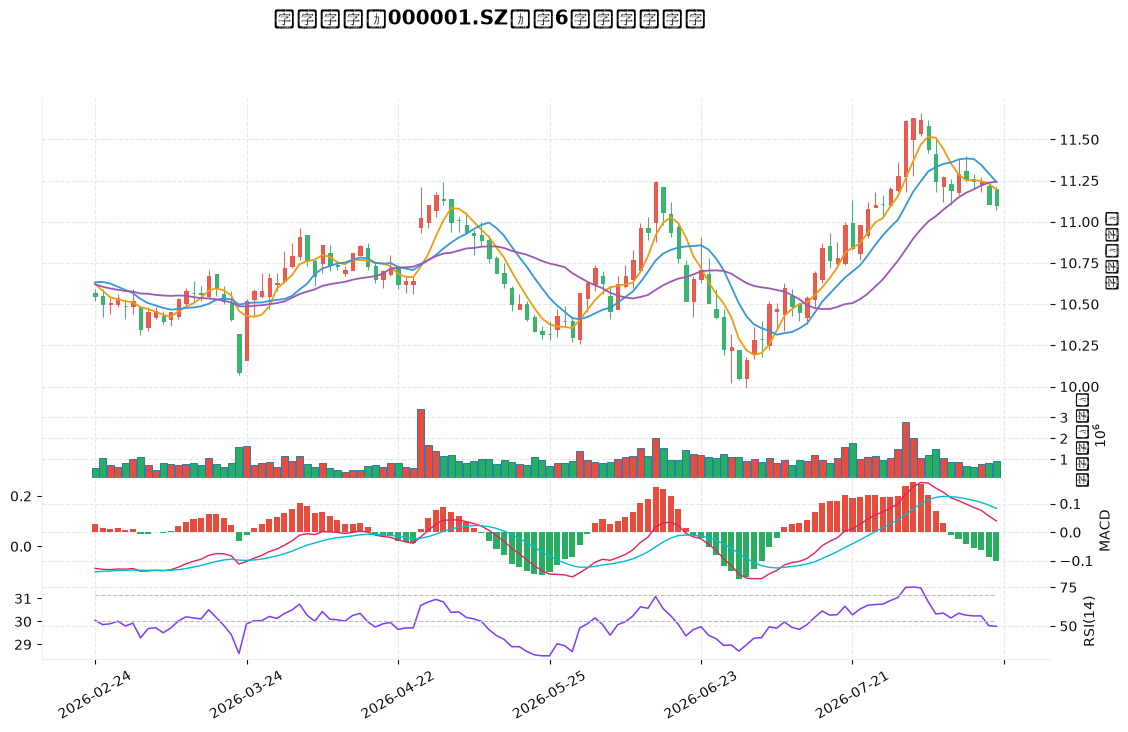

In [7]:

# ---- 绘图：K线四联图（charting.py 核心逻辑）----
UP, DOWN = "#e74c3c", "#27ae60"
mc = mpf.make_marketcolors(up=UP, down=DOWN, edge="inherit", wick="inherit", volume="inherit")
style = mpf.make_mpf_style(base_mpf_style="yahoo", marketcolors=mc, gridstyle="--",
                           gridcolor="#e8e8e8", facecolor="white", figcolor="white")
hist_colors = [UP if v >= 0 else DOWN for v in df["MACD"]]
apds = [
    mpf.make_addplot(df[f"MA{w}"], color=c, width=1.3)
    for w, c in zip(MA_WINDOWS, ["#f39c12", "#3498db", "#9b59b6"])
]
apds += [
    mpf.make_addplot(df["MACD"], type="bar", panel=2, color=hist_colors, width=0.8, ylabel="MACD"),
    mpf.make_addplot(df["DIF"], panel=2, color="#e91e63", width=1.0),
    mpf.make_addplot(df["DEA"], panel=2, color="#00bcd4", width=1.0),
    mpf.make_addplot(df[f"RSI{RSI_PERIOD}"], panel=3, color="#7d3cff", width=1.1, ylabel=f"RSI({RSI_PERIOD})"),
    mpf.make_addplot(pd.Series(70, index=df.index), panel=3, color="#bbbbbb", linestyle="--", width=0.8),
    mpf.make_addplot(pd.Series(30, index=df.index), panel=3, color="#bbbbbb", linestyle="--", width=0.8),
]
fig, axes = mpf.plot(
    df[["open", "high", "low", "close", "volume"]],
    type="candle", volume=True, addplot=apds, style=style,
    title=f"{NAME}（{CODE}.SZ）近{MONTHS}个月技术分析",
    ylabel="价格（元）", ylabel_lower="成交量（手）",
    figsize=(14, 8), panel_ratios=(4, 1, 1.4, 1),
    returnfig=True, datetime_format="%Y-%m-%d", xrotation=30,
)
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.savefig(f"{OUT_DIR}/平安银行K线图.png", dpi=200, facecolor="white")
plt.show()


**图 2**：双均线策略净值 vs 买入持有基准净值对比，展示策略是否跑赢基准。

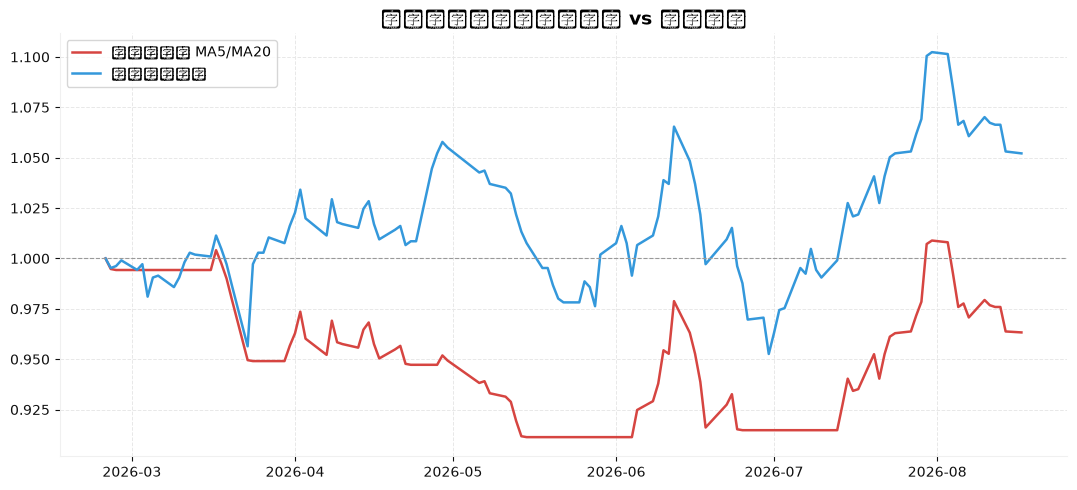

In [8]:

# ---- 绘图：策略 vs 基准对比 ----
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(bt.index, bt["strategy_equity"], color="#d64541", lw=1.8,
        label=f"双均线策略 MA{BT_FAST}/MA{BT_SLOW}")
ax.plot(bt.index, bt["benchmark_equity"], color="#3498db", lw=1.8, label="买入持有基准")
ax.axhline(1.0, color="#999999", lw=0.8, linestyle="--")
ax.set_title(f"{NAME}双均线策略收益 vs 基准收益", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(True, color="#e8e8e8", linestyle="--", linewidth=0.7)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.savefig(f"{OUT_DIR}/平安银行双均线回测对比图.png", dpi=200, facecolor="white")
plt.show()


In [9]:

# ---- 结果汇总与数据快照 ----
summary = pd.DataFrame({
    "指标": ["区间涨跌幅%", "策略收益%", "基准收益%", "超额收益%",
             "最大回撤%", "年化波动率%", "期末RSI"],
    "数值": [f"{stats['区间涨跌幅%']:+.2f}", f"{strat_total * 100:+.2f}",
            f"{bench_total * 100:+.2f}", f"{(strat_total - bench_total) * 100:+.2f}",
            f"{stats['最大回撤%']:.2f}", f"{stats['年化波动率%']:.2f}",
            f"{stats['期末RSI']:.1f}"],
})
display(summary)
df.to_csv(f"{OUT_DIR}/平安银行日K数据.csv", encoding="utf-8-sig")   # 数据快照便于复核
print("数据快照已保存：", f"{OUT_DIR}/平安银行日K数据.csv")


,指标,数值
0,区间涨跌幅%,+5.21
1,策略收益%,-3.67
2,基准收益%,+5.21
3,超额收益%,-8.88
4,最大回撤%,-10.59
5,年化波动率%,18.65
6,期末RSI,49.8


数据快照已保存： C:\Users\Administrator\Documents\ChatGPT\New project 2\output\jupyter-notebook/平安银行日K数据.csv


## 结果与结论

- 本 Notebook 全流程可复现：数据 → 指标 → 统计 → 回测 → 绘图，一键从上到下运行即可。
- 量化结果以表格输出（见上方汇总），图表以 200 DPI 内嵌展示，并同步保存到本目录。
- 双均线策略在震荡行情下容易被来回打脸，具体收益与基准对比见回测汇总——这本身就是一个
  值得在面试中展开讨论的策略局限点。

## 下一步

- 扩展：切换任意 A 股代码（修改 `CODE`），对比多只股票/多行业；
- 改进：换用次日开盘价成交 + 印花税，或引入止损/仓位管理；
- 结合：接入 `finance-analyst` 基本面研报，形成“技术面 + 基本面”双轮分析。